# Repeat a section

In this tutorial we build a 200 mm waveguide from four copies of one 50 mm
section. The section is solved and reduced only once; four copies of its
reduced model are joined into the chain. We check the chain against the exact
solution, compute its resonances and draw one of them over the whole chain.

A chain of identical cells is common: multi-cell cavities, cavity modules,
periodic filters. Solving the cell once, however many copies there are, is what
makes long chains cheap.

**Prerequisites:** [Join parts into one model](combine_parts.ipynb).

## 1. Build the chain

### 1.1 Add one section, four times

`n=4` repeats a part: four consecutive copies of the same section.

In [1]:
from cavsim3d.core.em_project import EMProject

proj = EMProject(name="repeated_sections", base_dir="./simulations", overwrite=True)

proj.create_primitive("rwg", name="cell", n=4, a=0.1, b=0.05, L=0.05, maxh=0.02)
list(proj.parts)

✅ Creating new project 'repeated_sections' at simulations\repeated_sections


['cell']

### 1.2 Read the layout

In [2]:
print(proj.geometry.describe_layout())

Main axis: Z (default). Parts follow the list order along +Z:
  1. cell x4: z = [0, 0.05] m
Mesh strategy: coupled (each unique part meshed and solved on its own, joined through port modes; repeated: cell (n=4))


The chain runs along +z: `cell x4`, four copies of a 0.05 m section. The mesh
strategy is
`coupled`: a repeated part is meshed and solved once on its own, and the copies
are joined through the modes of the ports that face each other. (Different
parts, each used once, are glued into one mesh, as in the previous tutorial.)

## 2. Solve the section once

### 2.1 Run the sweep

The copies are joined through their port modes, one per port (TE10). We
therefore sweep only up to 2.9 GHz: from 3.0 GHz on, TE20 and TE01 propagate as
well, and a join that should pass them would need them as port modes too (see
[How to set up port modes](../../how-to/port_modes.md)).

In [3]:
fom_res = proj.fds.solve(fmin=0.5, fmax=2.9, nsamples=25)

✅ Mesh strategy: coupled (repeated: cell (n=4)): each unique part is solved on its own and the parts are joined through their port modes.


✅ Solve plan:
  cell  geometry             compute   full-order solve, 25 samples



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 178
✅ Section 'cell': full-order solve


Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_10, kc=31.4159, sigma=+1
	port2 mode 0: TE_10, kc=31.4159, sigma=+1
Port eigenmodes complete: 2 total modes



FDS Solve: 0.5000 - 2.9000 GHz, 25 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 6.90s (total iteration steps: 2401)


✅ Netlist FOM stage complete: 1 unique section(s) for 4 instance(s)


Before it starts, `solve()` prints a plan with one line per unique part:
`cell ... compute`, a full-order solve. It ends with
`Netlist FOM stage complete: 1 unique section(s) for 4 instance(s)`.

### 2.2 Look at the section's result

`proj.fds.foms` holds the full-order result of the one unique section, a
50 mm piece of guide.

In [4]:
foms = proj.fds.foms
print(foms.keys)

['cell']


## 3. Reduce and join the copies

### 3.1 Reduce the section

In [5]:
roms = foms.reduce(tol=1e-6)

Model Order Reduction


Reduction complete: 4104 -> 9 DOFs (99.8% compression)


### 3.2 Join four copies

In [6]:
concat = roms.concatenate()
print(f"{len(concat.structures)} sections joined, "
      f"{concat.n_external_ports} external ports, {concat.coupled_dofs} unknowns")

4 sections joined, 2 external ports, 33 unknowns


Four sections, two external ports (the two ends of the chain), and a few dozen
unknowns for the whole chain.

### 3.3 Sweep the chain

In [7]:
res = concat.solve(fmin=0.5, fmax=2.9, nsamples=2000)


Concat Solve: 0.5 - 2.9 GHz, 2000 samples, system size 33


  Concat solve complete: 0.033s (2000 frequencies)


## 4. Check against the exact solution

Four 50 mm sections make a uniform 200 mm guide, the guide of the basics
tutorials. `RWGAnalytical` gives its exact response.

### 4.1 Compare the S-parameters

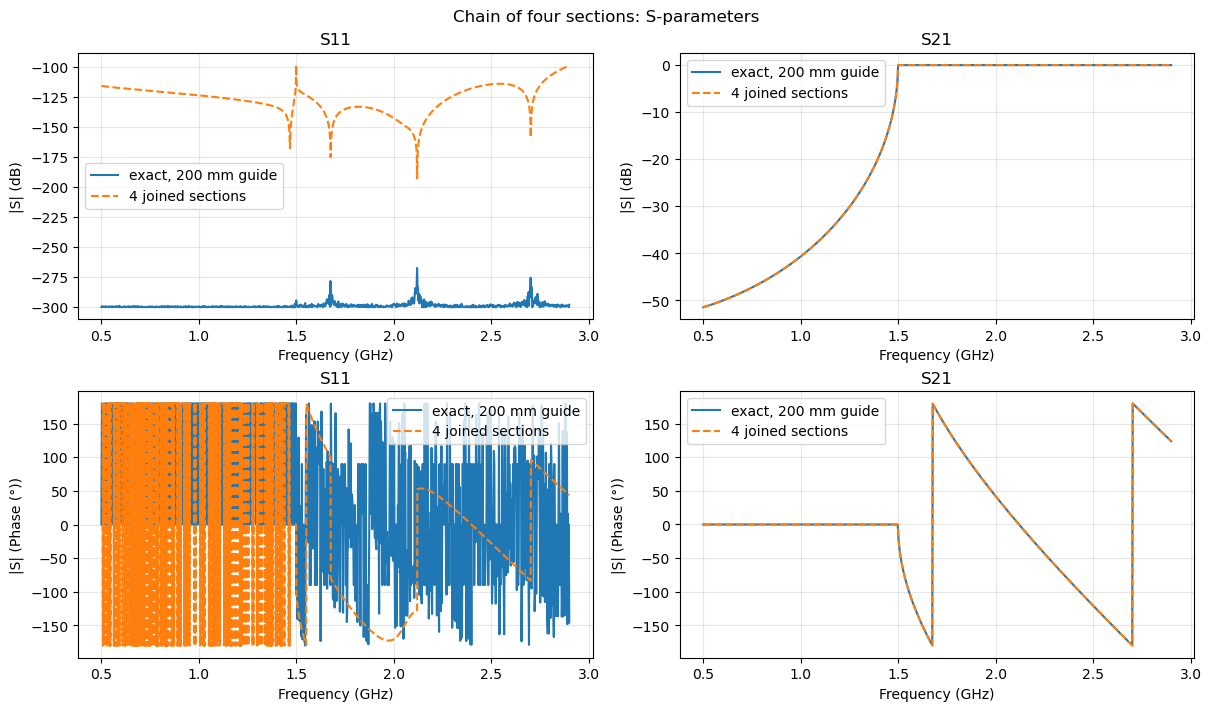

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from cavsim3d.analytical import RWGAnalytical

ana = RWGAnalytical(a=0.1, b=0.05, L=0.2, freq_range=(0.5, 2.9))

fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij in ("11", "21"):
    label = f"{ij[1]}(1){ij[0]}(1)"
    for kind in ("db", "phase"):
        ax = axs[f"{ij} {kind}"]
        ana.plot_s([label], plot_type=kind, ax=ax, label="exact, 200 mm guide")
        concat.plot_s([label], plot_type=kind, ax=ax, label="4 joined sections",
                      ls="--", title=f"S{ij}")
fig.suptitle("Chain of four sections: S-parameters")
plt.show()

$S_{21}$ of the chain follows the exact curve. As for every uniform guide, the
exact $S_{11}$ is zero and its panels show numerical noise.

### 4.2 Compare the Z-parameters

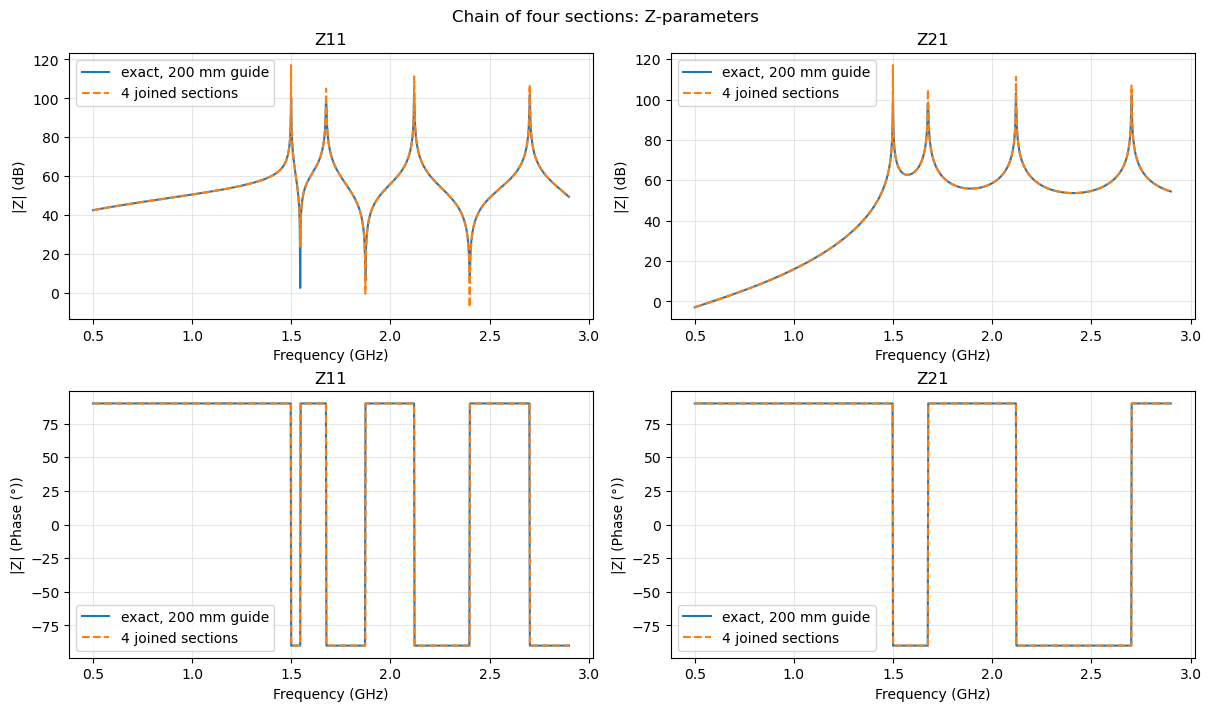

In [9]:
fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij in ("11", "21"):
    label = f"{ij[1]}(1){ij[0]}(1)"
    for kind in ("db", "phase"):
        ax = axs[f"{ij} {kind}"]
        ana.plot_z([label], plot_type=kind, ax=ax, label="exact, 200 mm guide")
        concat.plot_z([label], plot_type=kind, ax=ax, label="4 joined sections",
                      ls="--", title=f"Z{ij}")
fig.suptitle("Chain of four sections: Z-parameters")
plt.show()

The resonance peaks of the 200 mm guide are all there. A single 50 mm section
has none below 3 GHz: they belong to the chain, not to its parts.

### 4.3 Measure the difference

In [10]:
f = res["frequencies"]
err = np.abs(res["S"][:, 1, 0] - ana.s_parameters(f / 1e9)["S21"])
print(f"median |S21 - exact| above 1.6 GHz: {np.median(err[f > 1.6e9]):.1e}")

median |S21 - exact| above 1.6 GHz: 1.3e-05


## 5. Resonances of the chain

### 5.1 Compute them

`chain_eigenfrequencies` returns the resonances of the joined model inside a
band (in GHz), with an index for each.

In [11]:
idx, f_chain = concat.chain_eigenfrequencies(fmin_ghz=1.4, fmax_ghz=2.9)
exact = ana.all_eigenfrequencies(n_modes=4)

for i, fc in zip(idx, f_chain):
    print(f"mode {i}: {fc:.4f} GHz")
print("exact TE10p:", {k: round(v, 4) for k, v in exact.items()})

mode 0: 1.4990 GHz
mode 1: 1.6759 GHz
mode 2: 2.1199 GHz
mode 3: 2.7023 GHz
exact TE10p: {'TE100': 1.499, 'TE101': 1.6759, 'TE102': 2.1199, 'TE103': 2.7023}


The chain's resonances in this band are the TE100 (at the cutoff), TE101,
TE102 and TE103 modes of the 200 mm guide with magnetic end walls, as in
[Find resonances and look at fields](../basics/resonances_and_fields.ipynb).

### 5.2 Draw one over the whole chain

`reconstruct_chain_eigenmode` rebuilds the field of a chain resonance over all
four sections. It returns the field, a mesh of the whole chain and a label;
`draw` shows them.

In [12]:
from cavsim3d.utils.visualization import draw

cf, chain_mesh, label = concat.reconstruct_chain_eigenmode(int(idx[-1]), component="abs")
print(label)
# 3D view -- uncomment to open it when you run the notebook:
# draw(cf, chain_mesh)

abs(E) - chain eigenmode 3 @ 2.7023 GHz


The last mode in the band, TE103, has three half periods along the chain. The
field runs smoothly across the three joins between the sections.

## What we did

We built a chain from four copies of one section, solved and reduced that
section once, joined four copies of its reduced model, matched the chain to
the exact solution, and computed and drew its resonances.

**Next:** [Reuse a solved project](reuse_projects.ipynb) takes a section from a
project solved earlier instead of solving it again.

**Background:** [Parts, joins and netlists](../../explanation/parts_and_joins.md)
explains glued and coupled parts and what is checked at each join.